In [ ]:
# Install necessary packages if not already available
!pip install pandas scikit-learn matplotlib


In [ ]:
import pandas as pd

# Upload your file manually in Colab or mount Google Drive
from google.colab import files
uploaded = files.upload()

# Replace 'solana_data.csv' with your actual filename
df = pd.read_csv('/content/SOL-USD.csv')

# Show basic info
print(df.head())


Saving SOL-USD.csv to SOL-USD (1).csv
         Date      Open      High       Low     Close  Adj Close      Volume
0  2020-04-10  0.832005  1.313487  0.694187  0.951054   0.951054  87364276.0
1  2020-04-11  0.951054  1.049073  0.765020  0.776819   0.776819  43862444.0
2  2020-04-12  0.785448  0.956670  0.762426  0.882507   0.882507  38736897.0
3  2020-04-13  0.890760  0.891603  0.773976  0.777832   0.777832  18211285.0
4  2020-04-14  0.777832  0.796472  0.628169  0.661925   0.661925  16747614.0


In [ ]:
# Convert the Date column to datetime format and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Use previous day's closing price to predict current day's closing price
df['Previous_Close'] = df['Close'].shift(1)

# Drop rows with NaN (first row will have NaN in 'Previous_Close')
df_cleaned = df.dropna(subset=['Previous_Close', 'Close'])

# Keep only the necessary columns and rename for clarity
df_cleaned = df_cleaned[['Previous_Close', 'Close']]
df_cleaned.columns = ['Previous', 'Current']

# Show sample data
print(df_cleaned.head())



   Previous   Current
1  0.951054  0.776819
2  0.776819  0.882507
3  0.882507  0.777832
4  0.777832  0.661925
5  0.661925  0.646651


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Define predictors and target
X = df_cleaned[['Previous']]  # Predictor (previous day's price)
y = df_cleaned['Current']     # Target (current price)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train the model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Output model details
print(f"Intercept: {linreg.intercept_}")
print(f"Coefficient: {linreg.coef_[0]}")
print(f"Training R²: {linreg.score(X_train, y_train):.3f}")
print(f"Testing R²: {linreg.score(X_test, y_test):.3f}")

Intercept: 0.3123800624388835
Coefficient: 0.9930529783626434
Training R²: 0.995
Testing R²: 0.993


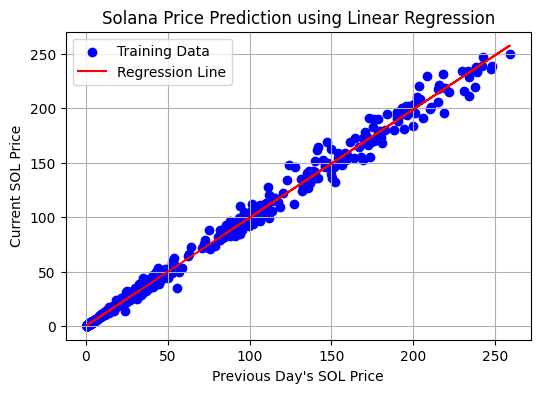

In [ ]:
# Plot training data and regression line
plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, color='blue', label="Training Data")
plt.plot(X_train, linreg.predict(X_train), color='red', label="Regression Line")
plt.xlabel("Previous Day's SOL Price")
plt.ylabel("Current SOL Price")
plt.title("Solana Price Prediction using Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Example: Predict tomorrow's price using today's price
today_price = float(input("Enter today’s Solana price: "))
predicted_price = linreg.predict([[today_price]])[0]
print(f"Predicted price for tomorrow: {predicted_price:.2f} USD")


Enter today’s Solana price: 133.57
Predicted price for tomorrow: 132.95 USD


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
